In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def chol_inv(x):
    c = np.linalg.cholesky(x)
    ci = np.linalg.solve(c, np.identity(x.shape[0]))
    return ci.T @ ci

In [3]:
K = 200
penalty = 1
reps = 400
qs_reps = np.zeros((reps, K))
for i in tqdm(range(reps)):
    X = np.array([(1, 1)])
    X_new = X.copy()
    qs = np.zeros(K)
    ks = np.arange(1, K+1)
    for k in ks:        
        XtX = np.zeros((2*k + 1, 2*k + 1))
        XtX[0, 0] = k * (k+1) / 2.
        ks_rev = np.arange(k, 0, -1)
        first_idx = np.arange(1, k+1).astype(int)
        second_idx = np.arange(k+1, 2*k+1).astype(int)
        XtX[first_idx, first_idx] = ks_rev
        XtX[first_idx, 0] = ks_rev
        XtX[0, first_idx] = ks_rev
        XtX[second_idx, second_idx] = ks_rev
        XtX[second_idx, 0] = ks_rev
        XtX[0, second_idx] = ks_rev
        Z1 = np.zeros((k, k))
        Z1[:] = first_idx
        Z2 = Z1.T.copy()
        tri_matrix = np.rot90(Z1 - Z2) >= 0
        XtX[k+1:, 1:(k+1)] = tri_matrix
        XtX[1:(k+1), k+1:] = tri_matrix
        Laplacian = np.zeros((2*k+1, 2*k+1))
        L_sub = np.eye(k) * 2
        L_sub[0, 0] = 1.
        L_sub[-1, -1] = 1.
        L_sub[np.arange(0, k-1), np.arange(1, k)] = -1
        L_sub[np.arange(1, k), np.arange(0, k-1)] = -1
        Laplacian[1:(k+1), 1:(k+1)] = L_sub
        Laplacian[(k+1):, (k+1):] = L_sub
        V0 = np.eye(2*k + 1) * penalty + Laplacian
        Vk = V0 + XtX
        Vki = chol_inv(Vk)
        theta = np.random.normal(scale=1., size=2*k+1)
        qs[k-1] = theta.T @ V0 @ Vki @ V0 @ theta
    qs_reps[i] = qs

100%|█████████████████████████████████████████| 400/400 [04:21<00:00,  1.53it/s]


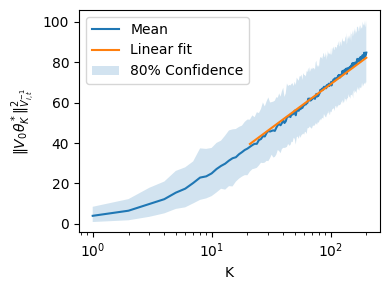

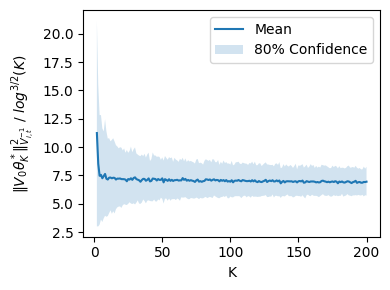

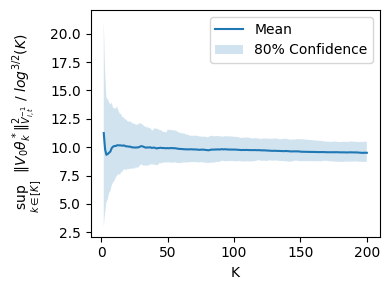

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4,3))
qs_mean = qs_reps.mean(axis=0)
qs_lower = np.percentile(qs_reps, 10, axis=0)
qs_upper = np.percentile(qs_reps, 90, axis=0)
lin_start = 20
X_mod = np.ones((K-lin_start, 2))
X_mod[:,1] = np.log(ks)[lin_start:]
mod = sm.OLS(qs[lin_start:], X_mod).fit()
plt.plot(ks, qs_mean, label="Mean")
plt.plot(ks[lin_start:], mod.fittedvalues, label="Linear fit")
plt.fill_between(ks, qs_lower, qs_upper, alpha=0.2, label="80% Confidence")
plt.legend()
plt.xscale("log")
plt.xlabel("K")
plt.ylabel("$\\Vert V_0 \\theta_K^* \\Vert^2_{V_{i,t}^{-1}}$")
fig.tight_layout()
fig.savefig("./figures/theta-star-sim-fig.pdf")
fig.savefig("./figures/theta-star-sim-fig.png")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(4,3))
ks2 = ks[1:]
qs2_rep = qs_reps[:, 1:] / np.log(ks2)**(3/2)
qs2_mean = qs2_rep.mean(axis=0)
qs2_lower = np.percentile(qs2_rep, 10, axis=0)
qs2_upper = np.percentile(qs2_rep, 90, axis=0)

plt.plot(ks2, qs2_mean, label="Mean")
plt.fill_between(ks2, qs2_lower, qs2_upper, alpha=0.2, label="80% Confidence")
plt.legend()
plt.xlabel("K")
plt.ylabel("$\\Vert V_0 \\theta_K^* \\Vert^2_{V_{i,t}^{-1}} \\ / \\ log^{3/2}(K)$")
fig.tight_layout()
fig.savefig("./figures/theta-star-sim-fig2.pdf")
fig.savefig("./figures/theta-star-sim-fig2.png")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(4,3))
qs3_rep = np.maximum.accumulate(qs_reps[:, 1:], axis=1)  / np.log(ks2)**(3/2)
qs3_mean = qs3_rep.mean(axis=0)
qs3_lower = np.percentile(qs3_rep, 10, axis=0)
qs3_upper = np.percentile(qs3_rep, 90, axis=0)

plt.plot(ks2, qs3_mean, label="Mean")
plt.fill_between(ks2, qs3_lower, qs3_upper, alpha=0.2, label="80% Confidence")
plt.legend()
plt.xlabel("K")
plt.ylabel("$\sup_{k \in [K]}\\ \\ \\Vert V_0 \\theta_k^* \\Vert^2_{V_{i,t}^{-1}} \\ / \\ log^{3/2}(K)$")
fig.tight_layout()
fig.savefig("./figures/theta-star-sim-fig3.pdf")
fig.savefig("./figures/theta-star-sim-fig3.png")
plt.show()